In [4]:
from IPython.display import Image

### 二次型

$$
y=(x^T)\cdot A\cdot x
$$

- “二次型”：所有项都是二次的齐次多项式。
- $f(x) = x^T A x$，其中 $A$ 通常是一个 Symmetric Matrix（对称矩阵）。
    - 结果是一个 scalar
$$x^T A x = x^T \left( \frac{A + A^T}{2} \right) x$$
- 如果 $A$ 不是对称阵，$A$ 的不对称性对二次型的值没有任何贡献。
    - $A = \underbrace{\frac{A + A^T}{2}}_{S \text{ (对称)}} + \underbrace{\frac{A - A^T}{2}}_{K \text{ (反对称)}}$
    - $x^T A x = x^T (S + K) x = x^T S x + x^T K x$
    - $x^T K x = (x^T K x)^T = x^T K^T x = x^T (-K) x = - (x^T K x)$（因为 $x^T K x$ 是一个标量，标量的转置等于其自身。）
        - $a = -a$ 意味着 $a=0$，所以 $x^T K x = 0$。
- 在求导时，如果默认 $A$ 是对称的，公式更简洁：
    - $\nabla_x (x^T A x) = 2Ax$
- 如果 $A$ 不是对称阵，没有任何坏处，只是没有必要。如果遇到一个非对称矩阵 $A$ 出现在 $x^T A x$ 中，您可以放心地直接用 $\frac{A+A^T}{2}$ 替换它，而不改变任何物理意义或数值结果。

### 正定性

把矩阵 A 放进二次型，可以绘制一组曲面地形图 
- 正定：像碗，只有一个最低点
- 负定：倒过来的碗，只有一个最高点
- 不定：马鞍面，上下方向同时存在
- 半正定：一个山谷，最小值不唯一
- 半负定：一条山脊，最大值不唯一

In [5]:
Image(url='./figs/definiteness.jpg', width=400)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置绘图风格
plt.style.use('default')

In [2]:

def plot_quadratic_form(A, title, ax, visual_type='surface'):
    """
    绘制二次型 y = x.T * A * x
    """
    # 1. 创建网格数据 (范围 -10 到 10)
    x = np.linspace(-10, 10, 30)
    y = np.linspace(-10, 10, 30)
    X, Y = np.meshgrid(x, y)
    
    # 2. 计算高度 Z
    # 二次型展开: Z = a*x^2 + (b+c)*x*y + d*y^2
    # A = [[a, b], [c, d]] (通常是对称矩阵 b=c)
    Z = A[0,0]*X**2 + (A[0,1] + A[1,0])*X*Y + A[1,1]*Y**2
    
    # 3. 绘制曲面
    # 使用 plot_surface + 线框效果来模拟原图风格
    surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.9, 
                           edgecolor='k', linewidth=0.3, antialiased=True)
    
    # 4. 设置视觉角度和标签
    ax.set_title(title, fontsize=12, pad=10, fontweight='bold')
    ax.set_xticks([]) # 隐藏坐标轴刻度以保持整洁
    ax.set_yticks([])
    ax.set_zticks([])
    
    # 5. 添加特殊标注 (根据矩阵性质)
    # 计算特征值来判断类型
    eigvals = np.linalg.eigvals(A)
    
    if np.all(eigvals > 1e-5): # 正定
        ax.scatter([0], [0], [0], color='blue', s=100, label='Minimum', zorder=10)
        ax.view_init(elev=30, azim=45)
        
    elif np.all(eigvals < -1e-5): # 负定
        ax.scatter([0], [0], [0], color='orange', s=100, label='Maximum', zorder=10)
        ax.view_init(elev=30, azim=45)
        
    elif np.any(eigvals > 1e-5) and np.any(eigvals < -1e-5): # 不定 (马鞍面)
        ax.view_init(elev=30, azim=-45)
        
    elif np.isclose(np.min(np.abs(eigvals)), 0): # 半定 (存在0特征值)
        # 绘制“谷底”或“山脊”线
        t = np.linspace(-10, 10, 50)
        if A[0,0] > 0 or A[1,1] > 0: # 半正定 (山谷)
            # 对于矩阵 [[1, -1], [-1, 1]]，最小值在 y=x 线
            ax.plot(t, t, np.zeros_like(t), color='blue', linewidth=3, zorder=10)
            ax.view_init(elev=30, azim=45)
        else: # 半负定 (山脊)
            ax.plot(t, t, np.zeros_like(t), color='orange', linewidth=3, zorder=10)
            ax.view_init(elev=30, azim=45)

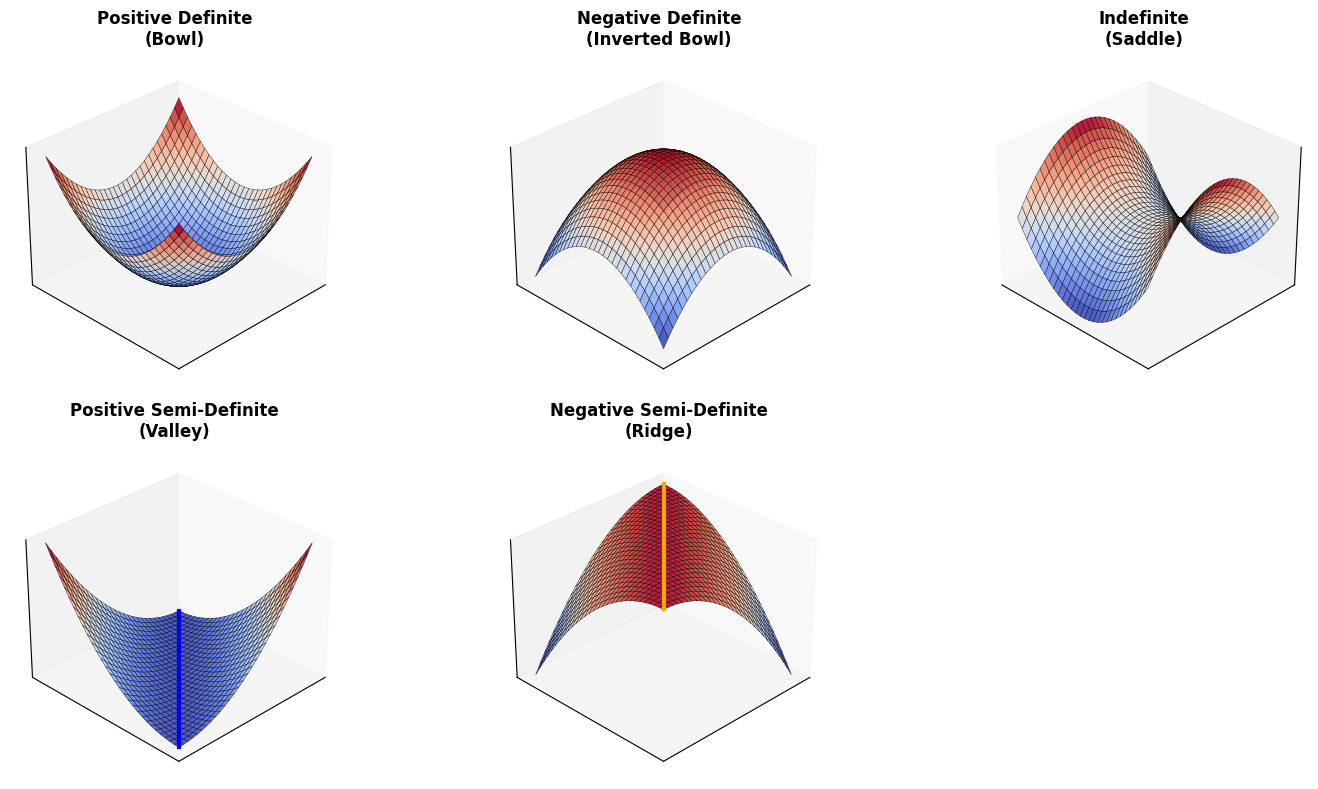

In [3]:

# 定义 5 种典型的矩阵
matrices = {
    "Positive Definite\n(Bowl)": np.array([[2, 0], [0, 2]]),           # 特征值: 2, 2
    "Negative Definite\n(Inverted Bowl)": np.array([[-2, 0], [0, -2]]), # 特征值: -2, -2
    "Indefinite\n(Saddle)": np.array([[2, 0], [0, -2]]),               # 特征值: 2, -2
    "Positive Semi-Definite\n(Valley)": np.array([[1, -1], [-1, 1]]),   # 特征值: 0, 2 (对角山谷)
    "Negative Semi-Definite\n(Ridge)": np.array([[-1, 1], [1, -1]])     # 特征值: -2, 0 (对角山脊)
}

# 创建画布
fig = plt.figure(figsize=(15, 8))

# 循环绘制
for i, (name, matrix) in enumerate(matrices.items()):
    if i < 3:
        pos = i + 1 # 第一行 3 个
    else:
        pos = i + 2 # 第二行 2 个 (居中一些，跳过位置4)
        if i == 3: pos = 7 # 调整布局位置
        if i == 4: pos = 9
    
    # 调整子图布局为 2行5列 的网格逻辑，方便摆放
    # 这里为了简单展示，使用 2x3 网格
    if i == 3: ax = fig.add_subplot(2, 3, 4, projection='3d')
    elif i == 4: ax = fig.add_subplot(2, 3, 5, projection='3d')
    else: ax = fig.add_subplot(2, 3, i+1, projection='3d')
    
    plot_quadratic_form(matrix, name, ax)

plt.tight_layout()